In [42]:
using Base.Threads

using Turing
using DriftDiffusionModels
using Random
using Distributions
using CSV
using DataFrames
using Dates
using StatsFuns
using MCMCChains
using StatsPlots

In [2]:
# read the data
rat_df = CSV.read("../data/processed_rat_data.csv.gz", DataFrame)
rat_df = rat_df[rat_df.daily .== "24 hr", :] # only keep 24 hour data

# preprocess the data to have numerics
replace!(rat_df[!, :choose_right], 0 => -1)

mapping = Dict("right" => 1, "left" => -1)
DataFrames.transform!(rat_df, :correct_side => ByRow(cs -> get(mapping, cs, missing)) => :correct_side_numeric)

names = unique(rat_df[!, "name"])

rat = names[5]

rat_of_interest = rat_df[rat_df.name .== rat, :]

# Convert string to DateTime
rat_of_interest.trial_datetime = DateTime.(rat_of_interest.trial_datetime, "yyyy-mm-dd HH:MM:SS")

# Extract hour and offset by 7.5 hours
rat_of_interest.hour_offset = mod.(hour.(rat_of_interest.trial_datetime) .+ minute.(rat_of_interest.trial_datetime)./60 .- 7.5, 24)

# Bin into integer hours (0-23)
rat_of_interest.hour_bin = floor.(Int, rat_of_interest.hour_offset)

"""
Bin trial data into time bins of specified duration.
"""
function bin_trials_by_time(rat_of_interest::DataFrame, bin_minutes::Real=60, offset_hours::Real=7.5)
    # Extract hour and offset
    hour_offset = mod.(hour.(rat_of_interest.trial_datetime) .+ 
                      minute.(rat_of_interest.trial_datetime)./60 .- offset_hours, 24)
    
    # Convert to minutes for binning
    minutes_offset = hour_offset .* 60
    
    # Number of bins in 24 hours
    n_bins = Int(24 * 60 / bin_minutes)
    
    # Bin into integer bins (0 to n_bins-1)
    bin_indices = floor.(Int, minutes_offset ./ bin_minutes)
    
    # Create results by bin
    results_by_bin = Vector{Vector{DDMResult}}(undef, n_bins)
    
    for b in 0:(n_bins-1)
        hour_indices = findall(bin_indices .== b)
        
        if isempty(hour_indices)
            results_by_bin[b+1] = DDMResult[]
            continue
        end
        
        # Extract data
        bin_rts = rat_of_interest.rt[hour_indices]
        bin_outcomes = rat_of_interest.choose_right[hour_indices]
        bin_stim_side = rat_of_interest.correct_side_numeric[hour_indices]
        
        # Create DDMResult objects
        results_by_bin[b+1] = [DDMResult(rt, choice, stim) 
                               for (rt, choice, stim) in zip(bin_rts, bin_outcomes, bin_stim_side)]
    end
    
    return results_by_bin
end

results_by_hour = bin_trials_by_time(rat_of_interest, 60)      # 60-min bins (24 bins)
# results_by_30min = bin_trials_by_time(rat_of_interest, 30)     # 30-min bins (48 bins)
# results_by_15min = bin_trials_by_time(rat_of_interest, 15)     # 15-min bins (96 bins)

24-element Vector{Vector{DDMResult}}:
 [DDMResult(1.1144, -1, 1), DDMResult(1.548, 1, 1), DDMResult(0.9523, -1, -1), DDMResult(0.9682, -1, 1), DDMResult(1.0481, 1, -1), DDMResult(1.9083, 1, 1), DDMResult(0.9224, -1, -1), DDMResult(2.5387, -1, -1), DDMResult(0.9497, -1, 1), DDMResult(1.5185, 1, 1)  …  DDMResult(0.8754, -1, -1), DDMResult(1.4373, 1, 1), DDMResult(1.0689, -1, -1), DDMResult(0.7783, -1, 1), DDMResult(1.0233, -1, -1), DDMResult(1.0283, -1, 1), DDMResult(1.1229, -1, -1), DDMResult(1.0028, -1, -1), DDMResult(1.3977, 1, 1), DDMResult(0.8532, -1, -1)]
 [DDMResult(0.7042, -1, 1), DDMResult(1.0024, -1, -1), DDMResult(0.883, 1, 1), DDMResult(1.5125, 1, 1), DDMResult(1.3795, 1, 1), DDMResult(0.696, -1, 1), DDMResult(0.8041, -1, -1), DDMResult(0.8387, -1, -1), DDMResult(0.6443, -1, -1), DDMResult(1.1365, 1, -1)  …  DDMResult(2.1811, 1, 1), DDMResult(0.7938, -1, -1), DDMResult(0.9897, -1, -1), DDMResult(1.3129, 1, 1), DDMResult(0.8661, -1, -1), DDMResult(1.1638, -1, 1), DDMResult(1.1

In [3]:
# sigmoid
σ(x) = inv(1 + exp(-x))

ddmloglike(rts, choices, stimulus, v, B, a₀, τ) = begin
    ll = 0.0
    for i in eachindex(rts)
        ll += logdensityof(B, v, a₀, τ, rts[i], choices[i], stimulus[i])
    end
    return ll
end

@model function bayesDDM(rts::Vector{Float64},
                choices:: Vector{Int},
                stimulus::Vector{Int},
                )

    N = length(rts)
    min_rt = minimum(rts)

    # Priors for global parameters
    vLog ~ Normal(log(2.0), 0.5)          # drift rate
    BLog ~ Normal(log(4.0), 0.5)          # boundary separation
    a₀ ~ Beta(2, 2)                     # starting point bias
    base_τ ~ Beta(2, 1)

    τ = min_rt * base_τ
    v = exp(vLog)
    B = exp(BLog)

    # Likelihood
    @addlogprob! ddmloglike(rts, choices, stimulus, v, B, a₀, τ)
end


bayesDDM (generic function with 2 methods)

In [4]:
NUnits = 24

chains = Vector{Chains}(undef, NUnits)

@threads for i in 1:NUnits
    rts = [x.rt for x in results_by_hour[i]]
    choices = [x.choice for x in results_by_hour[i]]
    stimulus = [Int(x.s) for x in results_by_hour[i]]

    println("Fitting hour bin $i with $(length(rts)) trials.")

    model = bayesDDM(rts, choices, stimulus)
    chain = sample(model, NUTS(), 1000, progress=false)

    chains[i] = chain
end

Fitting hour bin 7 with 1858 trials.
Fitting hour bin 15 with 652 trials.
Fitting hour bin 21 with 293 trials.
Fitting hour bin 17 with 420 trials.
Fitting hour bin 14 with 1555 trials.
Fitting hour bin 22 with 404 trials.
Fitting hour bin 5 with 1749 trials.
Fitting hour bin 16 with 387 trials.
Fitting hour bin 11 with 1367 trials.
Fitting hour bin 1 with 546 trials.
Fitting hour bin 24 with 183 trials.
Fitting hour bin 20 with 821 trials.
Fitting hour bin 12 with 1873 trials.
Fitting hour bin 18 with 1087 trials.
Fitting hour bin 3 with 913 trials.
Fitting hour bin 19 with 753 trials.
Fitting hour bin 10 with 1402 trials.
Fitting hour bin 13 with 1707 trials.
Fitting hour bin 23 with 271 trials.
Fitting hour bin 9 with 847 trials.


┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ 

Fitting hour bin 4 with 1426 trials.
Fitting hour bin 2 with 383 trials.


┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


Fitting hour bin 6 with 1709 trials.


┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


Fitting hour bin 8 with 876 trials.


┌ Info: Found initial step size
│   ϵ = 0.0125
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


In [29]:
level = 0.94
α = (1 - level) / 2     # 0.03
qs = [α, 1 - α]         # [0.03, 0.97]

summary_values = DataFrame(hour_bin=Int[],
                           param=String[],
                           mean=Float64[],
                           sd=Float64[],
                           q_low=Float64[],
                           q_high=Float64[])

for i in 1:NUnits
    chain = chains[i]

    params = ["vLog", "BLog", "a₀", "base_τ"]

    # use post-warmup samples
    for p in params
        mean_val = mean(chain[p][:501:end])
        sd_val = std(chain[p][:501:end])
        q_low = quantile(chain[p][:501:end], qs[1])
        q_high = quantile(chain[p][:501:end], qs[2])

        push!(summary_values, (i-1, p, mean_val, sd_val, q_low, q_high))
    end
end

df_vlog = filter(:param => ==("vLog"), summary_values)
df_v    = select(df_vlog, :hour_bin, :mean, :q_low, :q_high)

df_v.v_mean  = exp.(df_v.mean)
df_v.v_low   = exp.(df_v.q_low)
df_v.v_high  = exp.(df_v.q_high)


df_blog = filter(:param => ==("BLog"), summary_values)
df_B    = select(df_blog, :hour_bin, :mean, :q_low, :q_high)

df_B.B_mean  = exp.(df_B.mean)
df_B.B_low   = exp.(df_B.q_low)
df_B.B_high  = exp.(df_B.q_high)


min_rts = [minimum([x.rt for x in results_by_hour[i]]) for i in 1:NUnits]

df_baseτ = filter(:param => ==("base_τ"), summary_values)
df_τ     = select(df_baseτ, :hour_bin, :mean, :q_low, :q_high)

# hour_bin is 0-based (i-1), so we index min_rts with +1
scale = min_rts[df_τ.hour_bin .+ 1]

df_τ.τ_mean = df_τ.mean .* scale
df_τ.τ_low  = df_τ.q_low .* scale
df_τ.τ_high = df_τ.q_high .* scale




24-element Vector{Float64}:
 0.5253662438830604
 0.5899456359122387
 0.49426991277091487
 0.3616483808792249
 0.3683401995588562
 0.3584873095502404
 0.3676722503475164
 0.10529198883453547
 0.3217833546049623
 0.07296067849077356
 ⋮
 0.4745498578788183
 0.5739946037417897
 0.5645158925469367
 0.5514316483386397
 0.45616096202838996
 0.5547693591226035
 0.5385005865181055
 0.5205647760853036
 0.6738889179697324

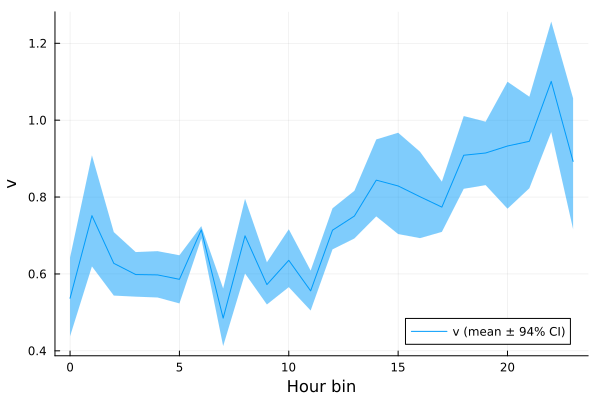

In [36]:
x  = df_v.hour_bin
m  = df_v.v_mean
lo = df_v.v_low
hi = df_v.v_high

p1 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "v",
    label  = "v (mean ± 94% CI)",
    legend = :bottomright,
)


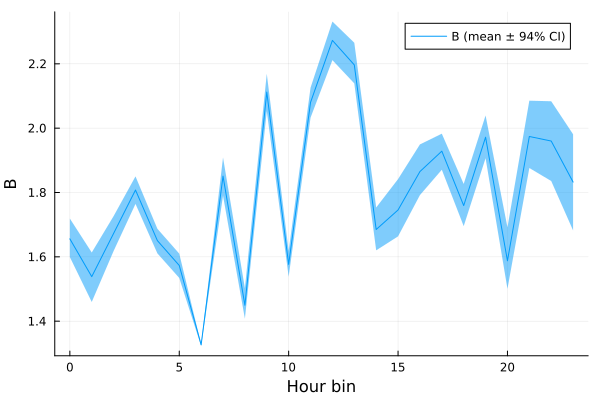

In [37]:
x  = df_B.hour_bin
m  = df_B.B_mean
lo = df_B.B_low
hi = df_B.B_high

p2 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "B",
    label  = "B (mean ± 94% CI)",
)


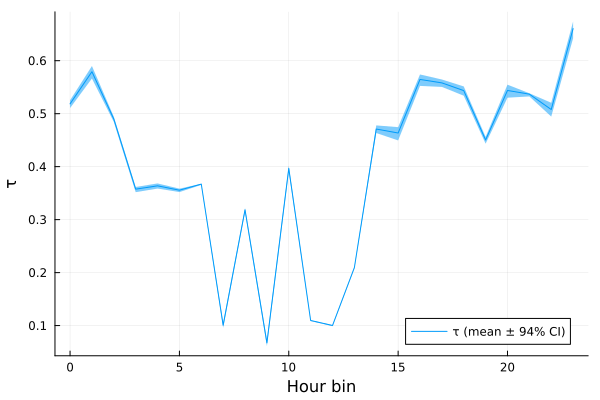

In [38]:
x  = df_τ.hour_bin
m  = df_τ.τ_mean
lo = df_τ.τ_low
hi = df_τ.τ_high

p3 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "τ",
    label  = "τ (mean ± 94% CI)",
)


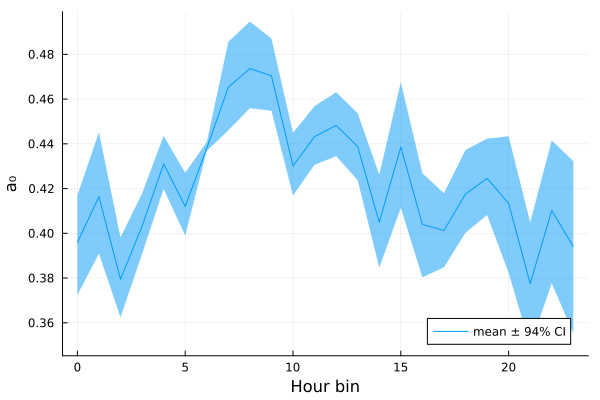

In [39]:
df_a0 = filter(:param => ==("a₀"), summary_values)

x  = df_a0.hour_bin
m  = df_a0.mean
lo = df_a0.q_low
hi = df_a0.q_high

p4 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "a₀",
    label  = "mean ± 94% CI",
    legend = :bottomright,
)

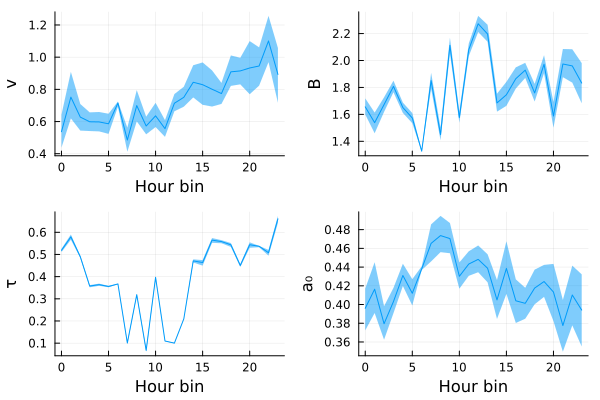

In [41]:
plots = [p1, p2, p3, p4] 

plot(plots...; layout = (2, 2), legend = false)

In [ ]:
@model function lapseBayesDDM(rts::Vector{Float64},
                              choice::Vector{Int},
                              stimulses::Vector{Int})

    N = length(rts)
    max_rt = maximum(rts)
    
    # priors
    logB  ~ Normal(log(2), 0.5)
    logV  ~ Normal(log(1), 0.5)
    a₀    ~ Beta(2, 2)
    τ_rel ~ Beta(2, 5)
    p_lapse ~ Beta(1, 10)    # lapses rare a priori

    τ = τ_rel * max_rt
    B = exp(logB)
    v = exp(logV)

    for i in eachindex(rts)
        rt  = rts[i]
        ch  = choice[i]
        stim = stimulses[i]

        # DDM log-density for this trial
        ll_ddm = logdensityof(B, v, a₀, τ, rt, ch, stim)

        # Lapse log-density for this trial
        ll_lapse_rt = logpdf(Uniform(0.0, max_rt), rt)

        ch_prop = (ch + 1) / 2
        ll_lapse_choice = logpdf(Bernoulli(0.5), ch_prop)

        ll_lapse = ll_lapse_rt + ll_lapse_choice

        m1 = ll_ddm   + log1p(-p_lapse)   # log(1 - p_lapse) + ll_ddm
        m2 = ll_lapse + log(p_lapse)      # log(p_lapse)     + ll_lapse

        mmax = max(m1, m2)
        @addlogprob! (mmax + log(exp(m1 - mmax) + exp(m2 - mmax)))
    end
end


lapseBayesDDM (generic function with 2 methods)

In [48]:
NUnits = 24

chains = Vector{Chains}(undef, NUnits)

@threads for i in 1:NUnits
    rts = [x.rt for x in results_by_hour[i]]
    choices = [x.choice for x in results_by_hour[i]]
    stimulus = [Int(x.s) for x in results_by_hour[i]]

    println("Fitting hour bin $i with $(length(rts)) trials.")

    model = lapseBayesDDM(rts, choices, stimulus)
    chain = sample(model, NUTS(), 1000, progress=false)

    chains[i] = chain
end

Fitting hour bin 23 with 271 trials.
Fitting hour bin 14 with 1555 trials.
Fitting hour bin 17 with 420 trials.
Fitting hour bin 9 with 847 trials.
Fitting hour bin 1 with 546 trials.
Fitting hour bin 24 with 183 trials.
Fitting hour bin 16 with 387 trials.
Fitting hour bin 11 with 1367 trials.
Fitting hour bin 12 with 1873 trials.
Fitting hour bin 22 with 404 trials.
Fitting hour bin 10 with 1402 trials.
Fitting hour bin 5 with 1749 trials.
Fitting hour bin 7 with 1858 trials.
Fitting hour bin 21 with 293 trials.
Fitting hour bin 19 with 753 trials.
Fitting hour bin 3 with 913 trials.
Fitting hour bin 20 with 821 trials.
Fitting hour bin 18 with 1087 trials.
Fitting hour bin 15 with 652 trials.
Fitting hour bin 13 with 1707 trials.


┌ Info: Found initial step size
│   ϵ = 0.01171875
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.006842041015625
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.043750000000000004
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215
┌ Info: Found initial step si

Fitting hour bin 2 with 383 trials.


┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


Fitting hour bin 4 with 1426 trials.


┌ Info: Found initial step size
│   ϵ = 0.03688964843750001
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


Fitting hour bin 8 with 876 trials.


┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


Fitting hour bin 6 with 1709 trials.


┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference C:\Users\ryansenne\.julia\packages\Turing\ArWoY\src\mcmc\hmc.jl:215


In [64]:
level = 0.94
α = (1 - level) / 2     # 0.03
qs = [α, 1 - α]         # [0.03, 0.97]

summary_values = DataFrame(hour_bin=Int[],
                           param=String[],
                           mean=Float64[],
                           sd=Float64[],
                           q_low=Float64[],
                           q_high=Float64[])

for i in 1:NUnits
    chain = chains[i]

    params = ["logV", "logB", "a₀", "τ_rel"]

    # use post-warmup samples
    for p in params
        mean_val = mean(chain[p][:501:end])
        sd_val = std(chain[p][:501:end])
        q_low = quantile(chain[p][:501:end], qs[1])
        q_high = quantile(chain[p][:501:end], qs[2])

        push!(summary_values, (i-1, p, mean_val, sd_val, q_low, q_high))
    end
end

df_vlog = filter(:param => ==("logV"), summary_values)
df_v    = select(df_vlog, :hour_bin, :mean, :q_low, :q_high)

df_v.v_mean  = exp.(df_v.mean)
df_v.v_low   = exp.(df_v.q_low)
df_v.v_high  = exp.(df_v.q_high)


df_blog = filter(:param => ==("logB"), summary_values)
df_B    = select(df_blog, :hour_bin, :mean, :q_low, :q_high)

df_B.B_mean  = exp.(df_B.mean)
df_B.B_low   = exp.(df_B.q_low)
df_B.B_high  = exp.(df_B.q_high)


min_rts = [maximum([x.rt for x in results_by_hour[i]]) for i in 1:NUnits]

df_baseτ = filter(:param => ==("τ_rel"), summary_values)
df_τ     = select(df_baseτ, :hour_bin, :mean, :q_low, :q_high)

# hour_bin is 0-based (i-1), so we index min_rts with +1
scale = min_rts[df_τ.hour_bin .+ 1]

df_τ.τ_mean = df_τ.mean .* scale
df_τ.τ_low  = df_τ.q_low .* scale
df_τ.τ_high = df_τ.q_high .* scale



24-element Vector{Float64}:
 0.5974259877461092
 0.5944837234135909
 0.5370085105398164
 0.4223376116025559
 0.3912240632838329
 0.44088102343060565
 0.39272434846695653
 0.39165639666698515
 0.4041424419154436
 0.4278046406461165
 ⋮
 0.5351687332689947
 0.6151563489981138
 0.6200167947482724
 0.5941509099711886
 0.5751868949910881
 0.5568929277149187
 0.7006407026796746
 0.6199057059595413
 0.7904528775654063

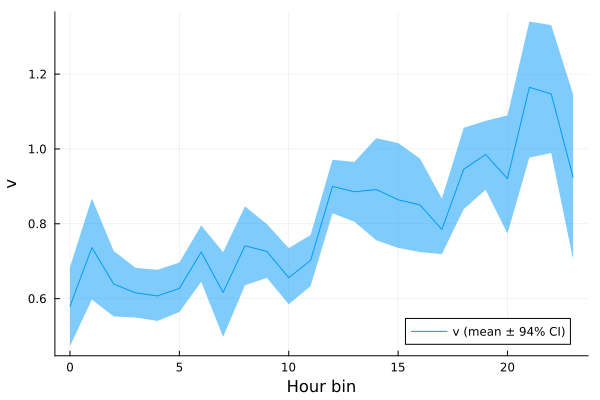

In [60]:
x  = df_v.hour_bin
m  = df_v.v_mean
lo = df_v.v_low
hi = df_v.v_high

p1 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "v",
    label  = "v (mean ± 94% CI)",
    legend = :bottomright,
)


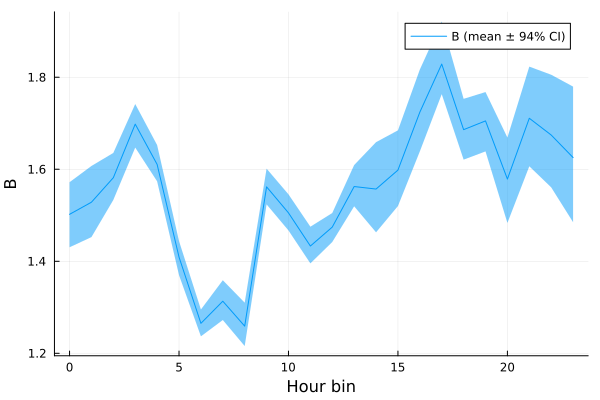

In [61]:
x  = df_B.hour_bin
m  = df_B.B_mean
lo = df_B.B_low
hi = df_B.B_high

p2 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "B",
    label  = "B (mean ± 94% CI)",
)


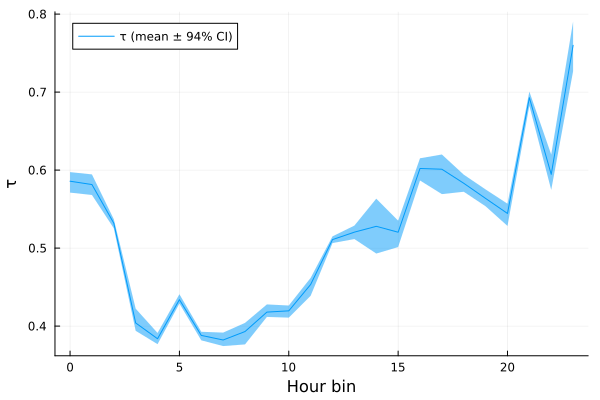

In [65]:
x  = df_τ.hour_bin
m  = df_τ.τ_mean
lo = df_τ.τ_low
hi = df_τ.τ_high

p3 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "τ",
    label  = "τ (mean ± 94% CI)",
)

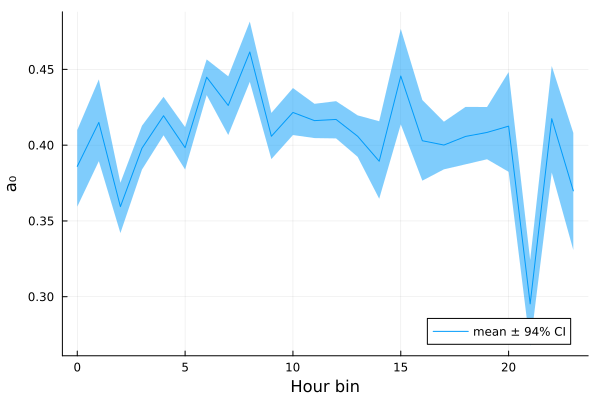

In [62]:
df_a0 = filter(:param => ==("a₀"), summary_values)

x  = df_a0.hour_bin
m  = df_a0.mean
lo = df_a0.q_low
hi = df_a0.q_high

p4 = plot(
    x, m;
    ribbon = (m .- lo, hi .- m),
    xlabel = "Hour bin",
    ylabel = "a₀",
    label  = "mean ± 94% CI",
    legend = :bottomright,
)

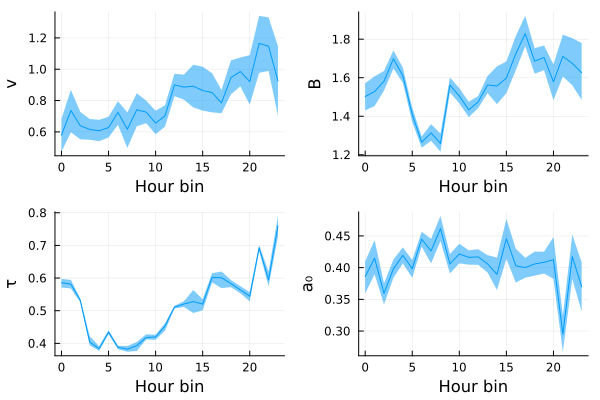

In [66]:
plots = [p1, p2, p3, p4] 

plot(plots...; layout = (2, 2), legend = false)

In [ ]:
@model function HierarchicalLapseBayesDDM(rts::Vector{Vector{Float64}},
                                     choice::Vector{Vector{Int}},
                                     stimulses::Vector{Vector{Int}},
                                     )

    n = length(rts)

    # Population priors
    μ_logB ~ Normal(log(2), 0.5)
    μ_logV ~ Normal(log(1), 0.5)
    μ_a₀   ~ Beta(2, 2)
    μ_τ_rel ~ Beta(2, 5)
    μ_p_lapse ~ Beta(1, 10)

    # Subject-level parameters
    

end